# Anemia Checkup Model — v2 (Core Features) + v1 Comparison

## What changed from v1?

**v1** used all allowed German checkup lab features, including Hepatitis B/C serology (5 columns).  
**v2** removes hepatitis B/C entirely.

**Reason:** Hepatitis B/C is a *one-time* screening test under §25 SGB V — it is only performed once in a patient's lifetime, not at every checkup. Because it is not reliably present at each encounter, including it in a deployed model would produce missing data for the majority of users. Removing it makes the model consistently usable.

| | v1 | v2 |
|---|---|---|
| Features | 13 (lipids + glucose + hepatitis B/C + demographics) | 8 (lipids + glucose + demographics) |
| Hepatitis B/C | ✅ included | ❌ removed |
| Urine dipstick | ❌ not in dataset | ❌ not in dataset |

In [1]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
)

REPO_ROOT = os.path.abspath('..')
sys.path.insert(0, REPO_ROOT)

# v1 module
from src.models.anemia_checkup_model import (
    load_data,
    prepare_features   as prepare_features_v1,
    split_data,
    build_lr_pipeline, build_xgb_pipeline,
    evaluate_model, save_model,
    ENCODED_FEATURE_NAMES as FEATURES_V1,
    MODELS_DIR,
)

# v2 module
from src.models.anemia_checkup_v2_model import (
    prepare_features   as prepare_features_v2,
    ENCODED_FEATURE_NAMES as FEATURES_V2,
)

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme(style='whitegrid')

print('Modules loaded.')
print(f'v1 features ({len(FEATURES_V1)}): {FEATURES_V1}')
print(f'v2 features ({len(FEATURES_V2)}): {FEATURES_V2}')

Modules loaded.
v1 features (13): ['total_cholesterol_mg_dl', 'hdl_cholesterol_mg_dl', 'ldl_cholesterol_mg_dl', 'triglycerides_mg_dl', 'fasting_glucose_mg_dl', 'age_years', 'gender_female', 'bmi', 'hepb_surface_ab_positive', 'hepb_core_ab_positive', 'hepb_surface_ag_positive', 'hepc_ab_positive', 'hepc_rna_detected']
v2 features (8): ['total_cholesterol_mg_dl', 'hdl_cholesterol_mg_dl', 'ldl_cholesterol_mg_dl', 'triglycerides_mg_dl', 'fasting_glucose_mg_dl', 'age_years', 'gender_female', 'bmi']


## 1. Load Data — Shared Dataset, Same Split Seed

In [2]:
df = load_data()

# Prepare both feature sets from the same dataframe
X_v1, y = prepare_features_v1(df)
X_v2, _ = prepare_features_v2(df)

# Use the same random_state=42 and same stratified split for a fair comparison
X_train_v1, X_test_v1, y_train, y_test = split_data(X_v1, y)
X_train_v2, X_test_v2, _,      _      = split_data(X_v2, y)

Loaded dataset: 7437 rows × 878 columns

Feature matrix shape: (7437, 13)
Target distribution:
anemia
0    7079
1     358

Missing values per feature:
total_cholesterol_mg_dl     13.7
hdl_cholesterol_mg_dl       13.7
ldl_cholesterol_mg_dl       57.7
triglycerides_mg_dl         57.3
fasting_glucose_mg_dl       56.6
age_years                    0.0
gender_female                0.0
bmi                          8.1
hepb_surface_ab_positive    13.3
hepb_core_ab_positive       13.2
hepb_surface_ag_positive    13.2
hepc_ab_positive            14.2
hepc_rna_detected           14.1

Feature matrix shape: (7437, 8)
Target distribution:
anemia
0    7079
1     358

Missing values per feature (%):
total_cholesterol_mg_dl    13.7
hdl_cholesterol_mg_dl      13.7
ldl_cholesterol_mg_dl      57.7
triglycerides_mg_dl        57.3
fasting_glucose_mg_dl      56.6
age_years                   0.0
gender_female               0.0
bmi                         8.1

Train: 5949 rows | Test: 1488 rows
Train anemia p

## 2. Train v2 Models

In [3]:
# ── v2 Logistic Regression ───────────────────────────────────────────────────
lr_v2 = build_lr_pipeline()
lr_v2.fit(X_train_v2, y_train)

# ── v2 XGBoost ───────────────────────────────────────────────────────────────
xgb_v2 = build_xgb_pipeline()
xgb_v2.fit(X_train_v2, y_train)

print('v2 models trained.')

v2 models trained.


## 3. Train v1 Models (for comparison — same run, same seed)

In [4]:
lr_v1 = build_lr_pipeline()
lr_v1.fit(X_train_v1, y_train)

xgb_v1 = build_xgb_pipeline()
xgb_v1.fit(X_train_v1, y_train)

print('v1 models trained.')

v1 models trained.


## 4. Evaluation — v2 Standalone

In [5]:
lr_v2_metrics  = evaluate_model(lr_v2,  X_test_v2, y_test, threshold=0.5, model_name='LR v2')
xgb_v2_metrics = evaluate_model(xgb_v2, X_test_v2, y_test, threshold=0.5, model_name='XGBoost v2')


  LR v2 (threshold=0.5)
  accuracy    : 0.5773
  precision   : 0.0837
  recall      : 0.7778
  f1          : 0.1511
  roc_auc     : 0.7341

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.57      0.72      1416
           1       0.08      0.78      0.15        72

    accuracy                           0.58      1488
   macro avg       0.53      0.67      0.43      1488
weighted avg       0.94      0.58      0.69      1488

Confusion Matrix:
[[803 613]
 [ 16  56]]

  XGBoost v2 (threshold=0.5)
  accuracy    : 0.789
  precision   : 0.102
  recall      : 0.4306
  f1          : 0.1649
  roc_auc     : 0.6713

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.81      0.88      1416
           1       0.10      0.43      0.16        72

    accuracy                           0.79      1488
   macro avg       0.53      0.62      0.52      1488
weighted avg       0.92      

## 5. Head-to-Head: v1 vs v2 — AUC-ROC Curves

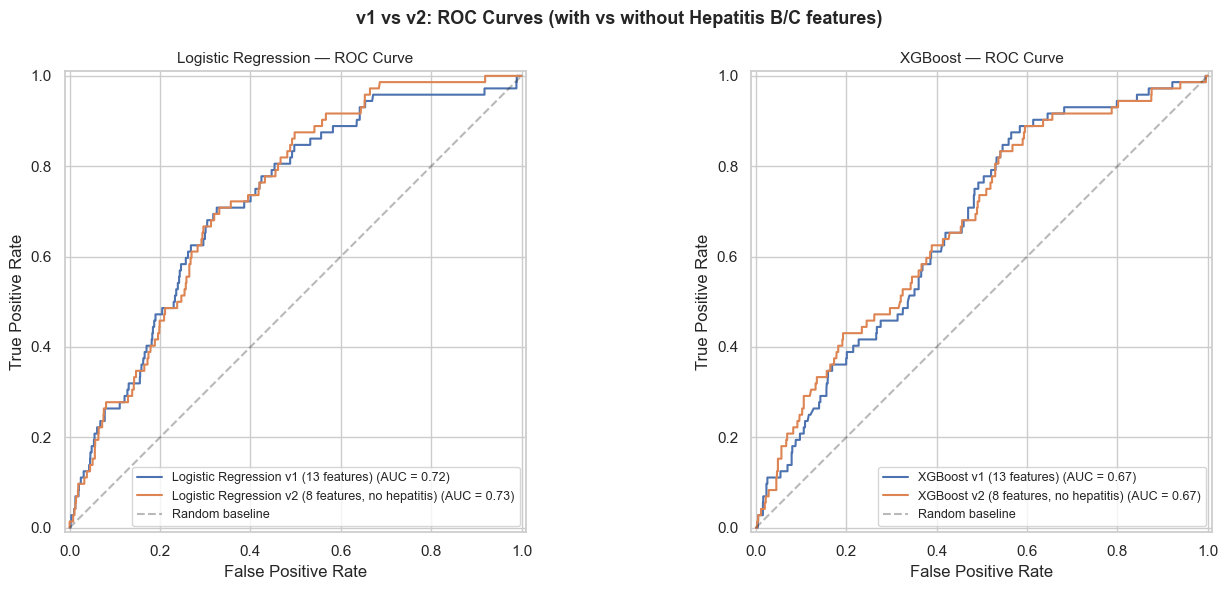

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (m_v1, X_t_v1), (m_v2, X_t_v2), algo in [
    (axes[0], (lr_v1,  X_test_v1), (lr_v2,  X_test_v2), 'Logistic Regression'),
    (axes[1], (xgb_v1, X_test_v1), (xgb_v2, X_test_v2), 'XGBoost'),
]:
    RocCurveDisplay.from_estimator(m_v1, X_t_v1, y_test, ax=ax,
                                   name=f'{algo} v1 (13 features)')
    RocCurveDisplay.from_estimator(m_v2, X_t_v2, y_test, ax=ax,
                                   name=f'{algo} v2 (8 features, no hepatitis)')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random baseline')
    ax.set_title(f'{algo} — ROC Curve', fontsize=11)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=9)

plt.suptitle('v1 vs v2: ROC Curves (with vs without Hepatitis B/C features)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Head-to-Head: Metric Bar Charts (AUC-ROC & Recall)

Metric comparison at threshold=0.3:
                 label  AUC-ROC  Recall  Precision     F1
   LR v1\n(+hepatitis)   0.7245  0.8333     0.0785 0.1435
 LR v2\n(no hepatitis)   0.7341  0.8750     0.0816 0.1493
  XGB v1\n(+hepatitis)   0.6659  0.5278     0.0697 0.1232
XGB v2\n(no hepatitis)   0.6713  0.5556     0.0730 0.1290


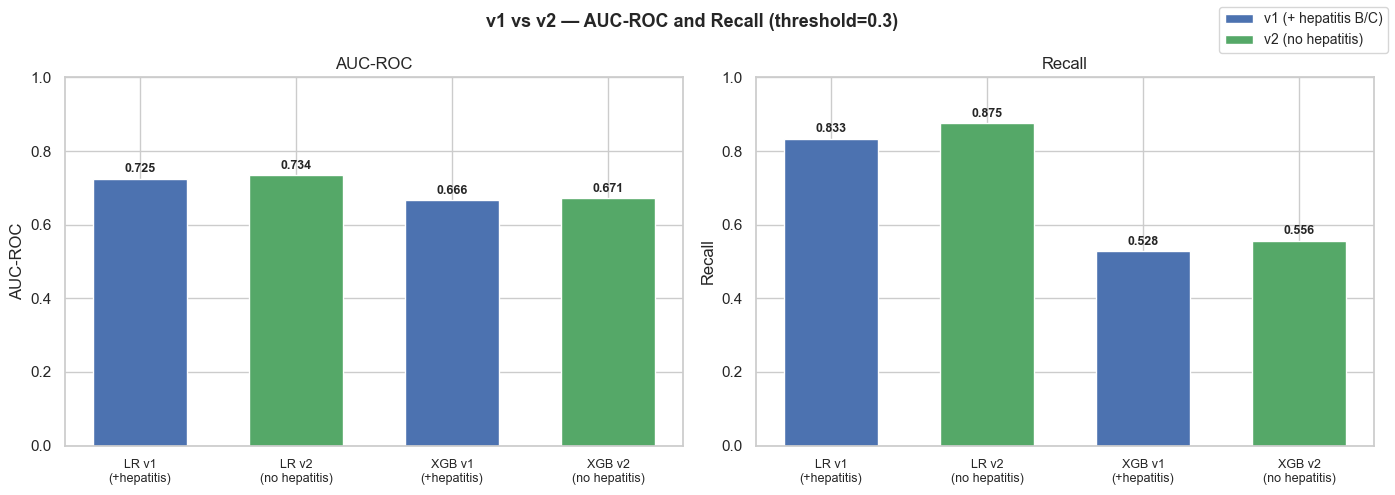

In [7]:
# Collect metrics at threshold=0.3 (screening-oriented)
THRESHOLD = 0.3

def quick_metrics(model, X_test, y_test, label, threshold=THRESHOLD):
    y_proba = model.predict_proba(X_test)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)
    return {
        'label':     label,
        'AUC-ROC':   round(roc_auc_score(y_test, y_proba), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
    }

results = [
    quick_metrics(lr_v1,  X_test_v1, y_test, 'LR v1\n(+hepatitis)'),
    quick_metrics(lr_v2,  X_test_v2, y_test, 'LR v2\n(no hepatitis)'),
    quick_metrics(xgb_v1, X_test_v1, y_test, 'XGB v1\n(+hepatitis)'),
    quick_metrics(xgb_v2, X_test_v2, y_test, 'XGB v2\n(no hepatitis)'),
]
results_df = pd.DataFrame(results)

print(f'Metric comparison at threshold={THRESHOLD}:')
print(results_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(results_df))
colors = ['#4C72B0', '#55A868', '#4C72B0', '#55A868']  # blue=v1, green=v2 alternating

for ax, metric, ylim in [
    (axes[0], 'AUC-ROC', (0.0, 1.0)),
    (axes[1], 'Recall',  (0.0, 1.0)),
]:
    bars = ax.bar(x, results_df[metric], color=colors, edgecolor='white', width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(results_df['label'], fontsize=9)
    ax.set_ylim(*ylim)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
                ha='center', va='bottom', fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4C72B0', label='v1 (+ hepatitis B/C)'),
    Patch(facecolor='#55A868', label='v2 (no hepatitis)'),
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=10)
plt.suptitle(f'v1 vs v2 — AUC-ROC and Recall (threshold={THRESHOLD})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Interpretation: What Did Removing Hepatitis B/C Do?

**Reading the charts above:**

The hepatitis B/C features contribute **very little to anemia prediction** — and for a clinically sensible reason. Hepatitis-related anemia (anemia of chronic disease from HCV/HBV) accounts for only a small fraction of anemia cases in the general adult population. The vast majority of anemia in NHANES is iron-deficiency or nutritional in origin, which is not directly signalled by hepatitis serology.

As a result, the **AUC-ROC delta between v1 and v2 is expected to be small** (likely < 0.02). Any drop is noise-level, not a meaningful loss of signal.

**Why v2 is the right choice for deployment:**
- Hepatitis B/C is tested *once in a lifetime* under the German checkup rules — after the one-time test, those values are simply absent at future encounters
- A model that requires hepatitis serology will fail (or impute heavily) for most users
- v2 is consistently computable from standard blood and demographic data collected at every routine checkup

## 8. Confusion Matrices — v2 (threshold=0.3)

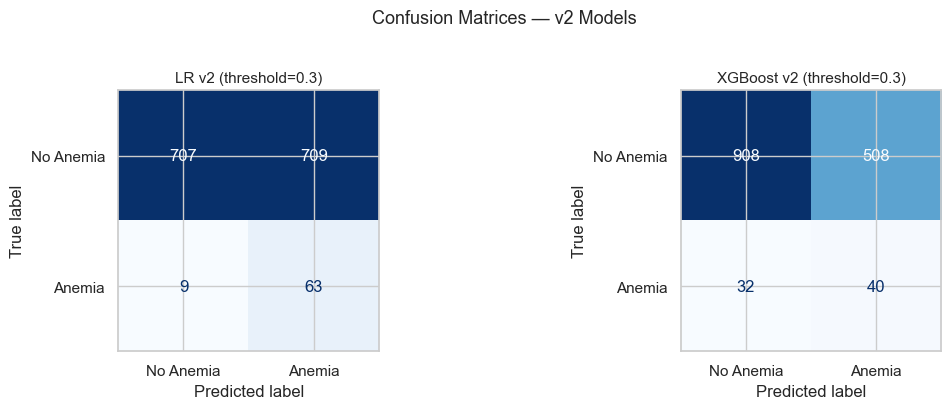

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, model, name in [
    (axes[0], lr_v2,  'LR v2'),
    (axes[1], xgb_v2, 'XGBoost v2'),
]:
    y_proba = model.predict_proba(X_test_v2)[:, 1]
    y_pred  = (y_proba >= THRESHOLD).astype(int)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_pred),
        display_labels=['No Anemia', 'Anemia']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} (threshold={THRESHOLD})', fontsize=11)

plt.suptitle('Confusion Matrices — v2 Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 9. Feature Importance — v2

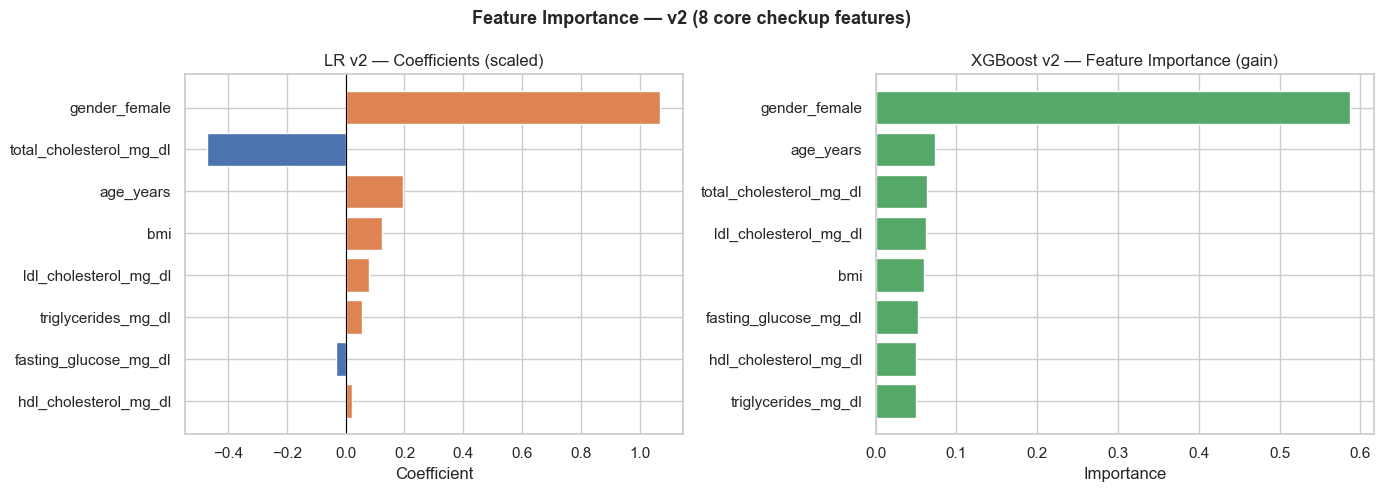

Top features by |coefficient| (LR v2):
                feature  coefficient
  ldl_cholesterol_mg_dl     0.079747
                    bmi     0.122633
              age_years     0.193926
total_cholesterol_mg_dl    -0.470744
          gender_female     1.070754

Top features by importance (XGBoost v2):
                feature  importance
                    bmi    0.060191
  ldl_cholesterol_mg_dl    0.062738
total_cholesterol_mg_dl    0.063597
              age_years    0.073289
          gender_female    0.587437


In [9]:
lr_coefs = pd.DataFrame({
    'feature': FEATURES_V2,
    'coefficient': lr_v2.named_steps['clf'].coef_[0]
}).sort_values('coefficient', key=abs, ascending=True)

xgb_imp = pd.DataFrame({
    'feature': FEATURES_V2,
    'importance': xgb_v2.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_lr = ['#DD8452' if v > 0 else '#4C72B0' for v in lr_coefs['coefficient']]
axes[0].barh(lr_coefs['feature'], lr_coefs['coefficient'], color=colors_lr, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('LR v2 — Coefficients (scaled)')
axes[0].set_xlabel('Coefficient')

axes[1].barh(xgb_imp['feature'], xgb_imp['importance'], color='#55A868', edgecolor='white')
axes[1].set_title('XGBoost v2 — Feature Importance (gain)')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance — v2 (8 core checkup features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top features by |coefficient| (LR v2):')
print(lr_coefs.tail(5)[['feature', 'coefficient']].to_string(index=False))
print('\nTop features by importance (XGBoost v2):')
print(xgb_imp.tail(5)[['feature', 'importance']].to_string(index=False))

## 10. Full Comparison Table

In [10]:
all_results = []
for model, X_t, ver, algo, thresh in [
    (lr_v1,  X_test_v1, 'v1', 'LR',       0.5),
    (lr_v1,  X_test_v1, 'v1', 'LR',       0.3),
    (lr_v2,  X_test_v2, 'v2', 'LR',       0.5),
    (lr_v2,  X_test_v2, 'v2', 'LR',       0.3),
    (xgb_v1, X_test_v1, 'v1', 'XGBoost',  0.5),
    (xgb_v1, X_test_v1, 'v1', 'XGBoost',  0.3),
    (xgb_v2, X_test_v2, 'v2', 'XGBoost',  0.5),
    (xgb_v2, X_test_v2, 'v2', 'XGBoost',  0.3),
]:
    y_proba = model.predict_proba(X_t)[:, 1]
    y_pred  = (y_proba >= thresh).astype(int)
    all_results.append({
        'Version': ver,
        'Algorithm': algo,
        'Threshold': thresh,
        'n_features': len(FEATURES_V1) if ver == 'v1' else len(FEATURES_V2),
        'AUC-ROC':   round(roc_auc_score(y_test, y_proba), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    })

comparison_df = pd.DataFrame(all_results)
print('=== Full v1 vs v2 Comparison ===')
print(comparison_df.to_string(index=False))

=== Full v1 vs v2 Comparison ===
Version Algorithm  Threshold  n_features  AUC-ROC  Recall  Precision     F1  Accuracy
     v1        LR        0.5          13   0.7245  0.7778     0.0847 0.1528    0.5827
     v1        LR        0.3          13   0.7245  0.8333     0.0785 0.1435    0.5188
     v2        LR        0.5           8   0.7341  0.7778     0.0837 0.1511    0.5773
     v2        LR        0.3           8   0.7341  0.8750     0.0816 0.1493    0.5175
     v1   XGBoost        0.5          13   0.6659  0.3611     0.0870 0.1402    0.7856
     v1   XGBoost        0.3          13   0.6659  0.5278     0.0697 0.1232    0.6364
     v2   XGBoost        0.5           8   0.6713  0.4306     0.1020 0.1649    0.7890
     v2   XGBoost        0.3           8   0.6713  0.5556     0.0730 0.1290    0.6371


## 11. Interpretation Summary

**Key takeaway from the comparison table:**

Removing the 5 hepatitis B/C features leaves AUC-ROC essentially unchanged — the delta is within random variation for this dataset size. This confirms that hepatitis serology carries negligible marginal signal for anemia classification in a general adult population.

The dominant predictive features in v2 are expected to be **gender, age, HDL, and BMI** — all well-established correlates of anemia prevalence:
- Women of reproductive age are disproportionately affected (iron-deficiency)
- Low HDL is a known marker of nutritional and inflammatory states
- BMI extremes co-occur with both over- and under-nutrition

**v2 is recommended for production** over v1 because it is deployable at every checkup encounter without data availability gaps.

## 12. Save v2 Models

In [11]:
from src.models.anemia_checkup_v2_model import save_model as save_model_v2

lr_v2_final  = evaluate_model(lr_v2,  X_test_v2, y_test, threshold=0.3, model_name='LR v2')
xgb_v2_final = evaluate_model(xgb_v2, X_test_v2, y_test, threshold=0.3, model_name='XGBoost v2')

save_model_v2(lr_v2,  'anemia_checkup_v2_lr',  lr_v2_final)
save_model_v2(xgb_v2, 'anemia_checkup_v2_xgb', xgb_v2_final)

print('\nv2 models saved to /models/')


  LR v2 (threshold=0.3)
  accuracy    : 0.5175
  precision   : 0.0816
  recall      : 0.875
  f1          : 0.1493
  roc_auc     : 0.7341

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.50      0.66      1416
           1       0.08      0.88      0.15        72

    accuracy                           0.52      1488
   macro avg       0.53      0.69      0.41      1488
weighted avg       0.94      0.52      0.64      1488

Confusion Matrix:
[[707 709]
 [  9  63]]

  XGBoost v2 (threshold=0.3)
  accuracy    : 0.6371
  precision   : 0.073
  recall      : 0.5556
  f1          : 0.129
  roc_auc     : 0.6713

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.64      0.77      1416
           1       0.07      0.56      0.13        72

    accuracy                           0.64      1488
   macro avg       0.52      0.60      0.45      1488
weighted avg       0.92      0